# Customer segmentation analysis
## Business understanding
### Business problem
The mall wants to increase sales by understanding customer purchasing behaviour and identify the different segments

### Analysis objective
segment customers according to income and spending patterns to identify high value customers, possible growth opportunities and segment specific marketing strategies

### Key questions
1. Who are the highest value customers?
2. What customer segments exist?
3. Which segments have the greatest spending potential?
4. How should marketing engage each segment

## Data understanding
The dataset contains demographics and spending information on mall customers

The dataset contains the following variables:
1. customerID (uniquely identifies each customer)
2. Gender (customer gender)
3. Age (customer age)
4. Annual income (estimated income in thousand $)
5. Spending score (score assigned by the mall based on spending behaviour from 1-100)

### Observations
- Age can be used to identify the differences between customer groups
- Annual income can be used to measure purchasing power
- Spending score can be used as proxy for customer spending behaviour

### Data limitations
1. No transaction amounts
2. No product preference
3. No visit frequency

The analysis will focus on customer segmentation, rather than retention due to the data limitations

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("../data/Mall_Customers.csv")

In [22]:
df.shape

(200, 5)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [24]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [25]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Exploratory data analysis

To identify the customer segments, annual income and spending score were chosen as the variables for analysis.
They are chosen because each directly influence the business goal (increasing revenue)

- how much they earn, influences how much they can spend
- how they spend influences sales
- together they will help identify high value customers, customers with high spending potential and how marketing teams can engage with each segment

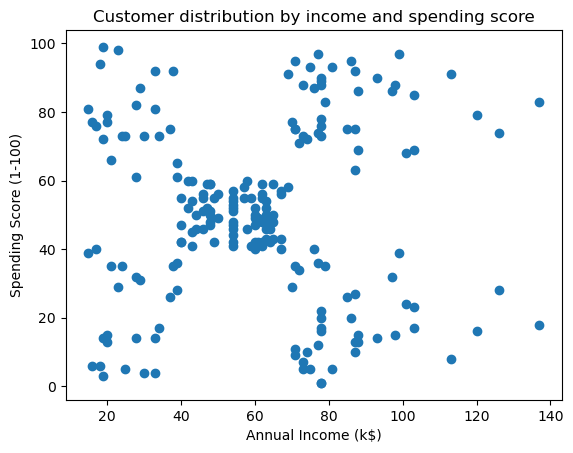

In [28]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer distribution by income and spending score")


plt.show()

## Observations
The scatter plot reveals approximately 5 customer groups based on annual income and spending score

Key observations:
- A large group of customers with average income and average spending behaviour appear in the centre of the distribution (Average customers)
- A group of high income and high spending power represents the premium customers (High value customers)
- A group of high income and low spending may represent an opportunity for the marketing team to target them (Growth opportunity customers)
- A group of low income and high spending power has strong purchasing behaviour but low purchasing power (High engagement customers)
- A group of low income and low spending have the lowest activity. (Low value customers)

The central segment may be the typical customer profile of the mall

## Segmentation
use k means to create 5 clusters

In [29]:
from sklearn.cluster import KMeans

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

c:\Users\gugun\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [30]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [31]:
# 1. Look at the coordinates of your 5 centers to see where they sit
centers = pd.DataFrame(kmeans.cluster_centers_, columns=["Annual Income (k$)", "Spending Score (1-100)"])

# 2. Programmatically assign names based on absolute thresholds instead of relative medians
def assign_exact_name(row):
    inc = row["Annual Income (k$)"]
    score = row["Spending Score (1-100)"]
    
    if 40 <= inc <= 70 and 40 <= score <= 60:
        return "Average Customers"
    elif inc > 70 and score > 60:
        return "Premium Customers"
    elif inc > 70 and score < 40:
        return "Affluent Low Spenders"
    elif inc < 40 and score > 60:
        return "High-Spending Budget Customers"
    else:
        return "Budget Customers"

# 3. Create the direct lookup dictionary and map it to your dataframe
centers["Segment"] = centers.apply(assign_exact_name, axis=1)
cluster_names = centers["Segment"].to_dict()

df["Segment"] = df["Cluster"].map(cluster_names)

In [32]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Budget Customers
1,2,Male,21,15,81,2,High-Spending Budget Customers
2,3,Female,20,16,6,4,Budget Customers
3,4,Female,23,16,77,2,High-Spending Budget Customers
4,5,Female,31,17,40,4,Budget Customers


In [33]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
195,196,Female,35,120,79,1,Premium Customers
196,197,Female,45,126,28,3,Affluent Low Spenders
197,198,Male,32,126,74,1,Premium Customers
198,199,Male,32,137,18,3,Affluent Low Spenders
199,200,Male,30,137,83,1,Premium Customers


## Interpretation of segments
The identified segments have different customer behaviour, based on income level and spending activity. Each segment needs unique and targeted marketing strategy.


### Premium Customers
Characteristics:
* High annual income
*	High spending score

**Interpretation:**
these customers demonstrate both high engagement and purchase power. This suggests they are valuable customers and should be retained long term



### Average Customers
Characteristics:
* Average income
* Average spending score

**Interpretation:**
these customers have average income and also average spending


### Affluent Low Spenders
Characteristics:
* High annual income
* Low spending score

**Interpretation:**
These customers have the ability to spend more, however they spend less. The opportunity is to increase their spending through targeted marketing


### High-Spending Budget Customers
Characteristics:
* Low annual income
*	High spending score

**Interpretation:**
These customers have high engagement with low purchasing power. To retain them maintain affordability to keep their interest in the mall.


### Budget Customers
Characteristics:
* Low annual income
* Low spending score

**Interpretation:**
These customers have low purchasing power and a low income. The marketing strategy could be targeting their values and letting the products appeal to them. They have potential for future growth


This analysis shows that customers have different purchasing power and engagement. The business should not market to all the same way, rather create specific marketing approach to each segment.

## Segments analysis

In [34]:
average_age_per_segment = df.groupby("Segment")["Age"].mean()

average_age_per_segment

Segment
Affluent Low Spenders             41.114286
Average Customers                 42.716049
Budget Customers                  45.217391
High-Spending Budget Customers    25.272727
Premium Customers                 32.692308
Name: Age, dtype: float64

In [35]:
segment_counts = df["Segment"].value_counts()
segment_counts

Segment
Average Customers                 81
Premium Customers                 39
Affluent Low Spenders             35
Budget Customers                  23
High-Spending Budget Customers    22
Name: count, dtype: int64

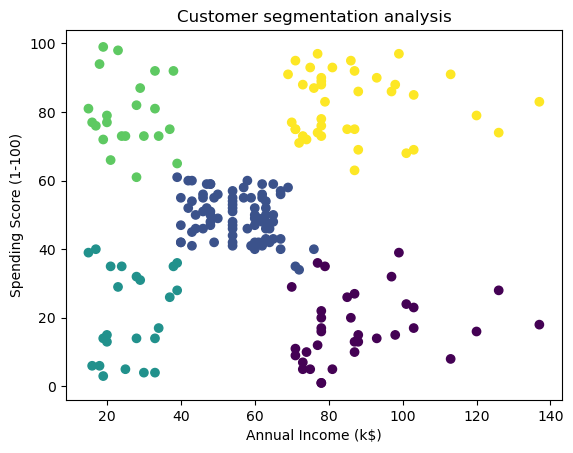

In [36]:
df["Segment_code"] = df["Segment"].astype("category").cat.codes

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Segment_code"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer segmentation analysis")

plt.show()

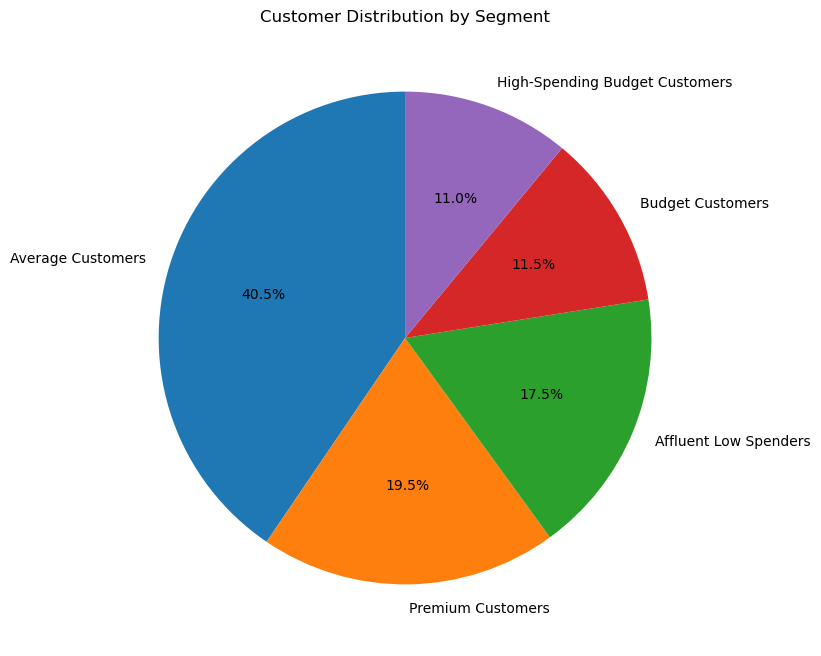

In [37]:
plt.figure(figsize=(8, 8))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Segment")

plt.show()

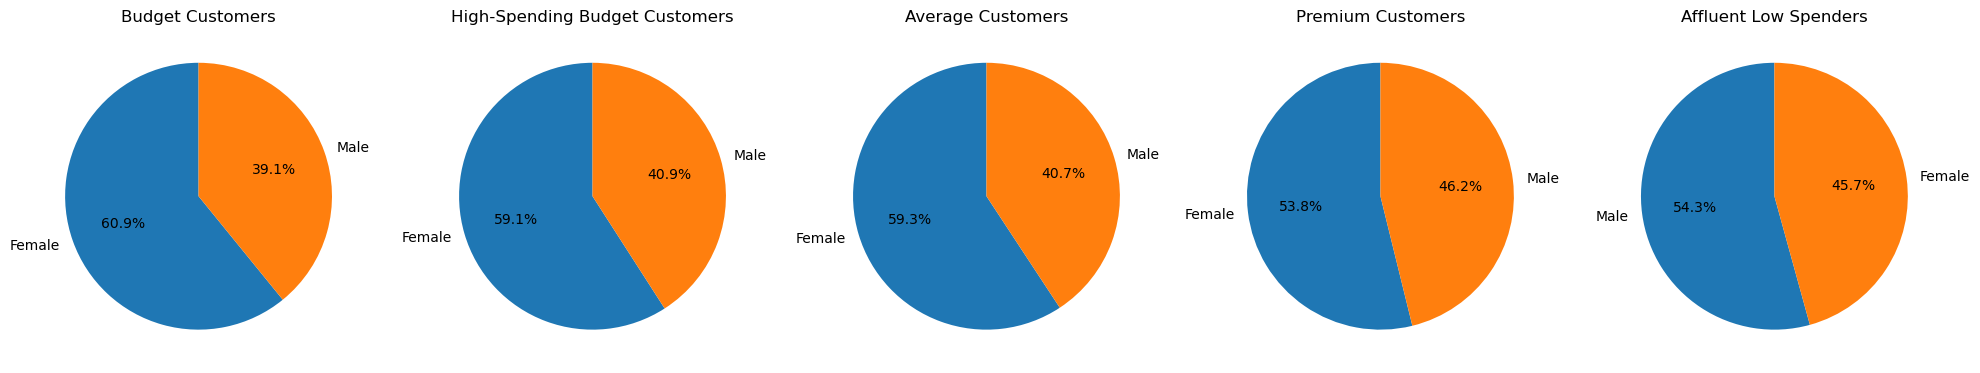

In [38]:
segments = df["Segment"].unique()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, segment in zip(axes, segments):
    gender_counts = (df[df["Segment"] == segment]["Gender"].value_counts()
    )

    ax.pie(
        gender_counts,
        labels=gender_counts.index,
        autopct="%1.1f%%",
        startangle=90
    )

    ax.set_title(segment)

plt.tight_layout()
plt.show()

## Observation
* Average Customers make up the highest percentage of customers
* High-Spending Budget Customers make up the least percentage of customers

* female customers dominate

## Conclusion

This analysis identified 5 segments based on income and spending behaviour.

The results show that the customers in each segment have a different level of engagement and income. Hence they require a unique and different approach to effectively market to them.

The business should focus on:
-	Retaining Premium Customers
-	Triggering more engagement of the Affluent Low Spenders
-	Rewarding High-Spending Budget and Average Customers to keep them loyal
-	Building a relationship with Budget Customers